In [2]:
%pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   -- ------------------------------------ 20.5/306.1 kB 330.3 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/306.1 kB 495.5 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/306.1 kB 495.5 kB/s eta 0:00:01
   ------- ------------------------------- 61.4/306.1 kB 273.8 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/306.1 kB 302.7 kB/s eta 0:00:01
   ------------- ------------------------ 112.6/306.1 kB 437.6 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/306.1 kB 361.0 kB/s eta 0:00:01
   -------------------- ----------------- 163.8/306.1 kB 409.6 kB/s eta 0:00:01
   ----------------------------- -------- 235.5/306.1 kB 554.9 kB/s eta 0:00:

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


✅ All libraries imported and NLTK data downloaded!


In [3]:

# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (run this once)
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("✅ All libraries imported and NLTK data downloaded!")

✅ All libraries imported and NLTK data downloaded!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tooba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ Data loaded successfully!
Shape: 14640 rows, 15 columns

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Sentiment distribution:
negative    9178
neutral     3099
positive    2363
Name: airline_sentiment, dtype: int64


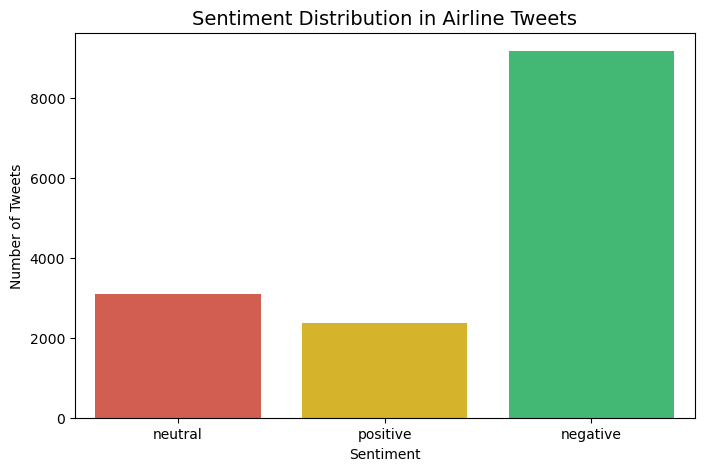

In [4]:
# Cell 2: Load data from your exact file path
file_path = r"C:\Users\Tooba\Desktop\Tweets.csv"

# Check if file exists
import os
if not os.path.exists(file_path):
    print(f"❌ File not found at: {file_path}")
    print("Please check the file name and path.")
else:
    df = pd.read_csv(file_path)
    print("✅ Data loaded successfully!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Show first 5 rows
    print("\nFirst 5 rows:")
    display(df.head())
    
    # Check sentiment distribution
    print("\nSentiment distribution:")
    print(df['airline_sentiment'].value_counts())
    
    # Visualize sentiment counts
    plt.figure(figsize=(8,5))
    sns.countplot(x='airline_sentiment', data=df, palette=['#E74C3C', '#F1C40F', '#2ECC71'])
    plt.title('Sentiment Distribution in Airline Tweets', fontsize=14)
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Tweets')
    plt.show()

In [5]:
# Cell 3: Clean the tweet text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Handle missing values
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions and hashtags (keep the words)
    text = re.sub(r'@\w+|#', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)
df['cleaned_text_no_stop'] = df['cleaned_text'].apply(remove_stopwords)

print("✅ Text cleaning complete!")
print("\nSample before and after cleaning:")
display(df[['text', 'cleaned_text']].head(5))

✅ Text cleaning complete!

Sample before and after cleaning:


,text,cleaned_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it



📊 VADER Accuracy vs Actual Labels: 0.00%


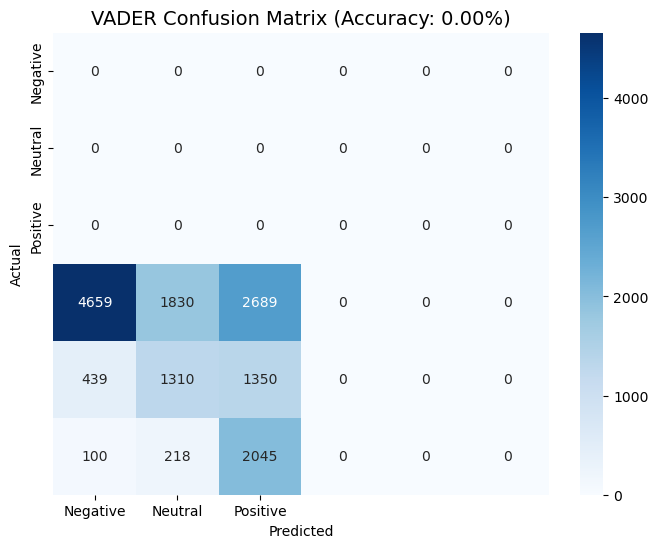

In [6]:
# Cell 4: VADER Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if text == "":
        return "Neutral"
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply VADER
df['vader_sentiment'] = df['cleaned_text'].apply(get_vader_sentiment)

# Calculate accuracy
vader_acc = accuracy_score(df['airline_sentiment'], df['vader_sentiment'])
print(f"\n📊 VADER Accuracy vs Actual Labels: {vader_acc:.2%}")

# Confusion matrix
cm = confusion_matrix(df['airline_sentiment'], df['vader_sentiment'])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title(f'VADER Confusion Matrix (Accuracy: {vader_acc:.2%})', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


📊 Logistic Regression Accuracy: 79.51%

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.94      0.87      1889
     neutral       0.66      0.47      0.55       580
    positive       0.83      0.62      0.71       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.78      2928



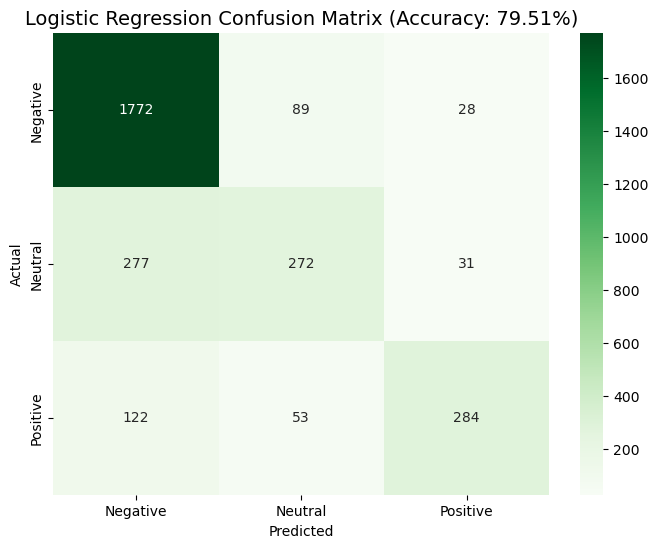


🔝 Top 10 Positive Words:
   hours: 3.6704
   worst: 3.0692
   delayed: 2.7982
   hour: 2.7497
   hold: 2.6306
   hrs: 2.4866
   delay: 2.2623
   fix: 2.2198
   customers: 2.1635
   lost: 2.1626

🔽 Top 10 Negative Words:
   thank: -4.1960
   thanks: -3.7771
   love: -2.1882
   great: -2.1228
   awesome: -2.0366
   amazing: -1.8502
   cant wait: -1.7972
   worries: -1.7101
   kudos: -1.5802
   best: -1.5672


In [7]:
# Cell 5: Train a Machine Learning model
# Prepare features (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['cleaned_text_no_stop'])
y = df['airline_sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Logistic Regression Accuracy: {lr_acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title(f'Logistic Regression Confusion Matrix (Accuracy: {lr_acc:.2%})', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance (top words)
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]
top_positive_idx = np.argsort(coefs)[-10:][::-1]
top_negative_idx = np.argsort(coefs)[:10]

print("\n🔝 Top 10 Positive Words:")
for idx in top_positive_idx:
    print(f"   {feature_names[idx]}: {coefs[idx]:.4f}")

print("\n🔽 Top 10 Negative Words:")
for idx in top_negative_idx:
    print(f"   {feature_names[idx]}: {coefs[idx]:.4f}")

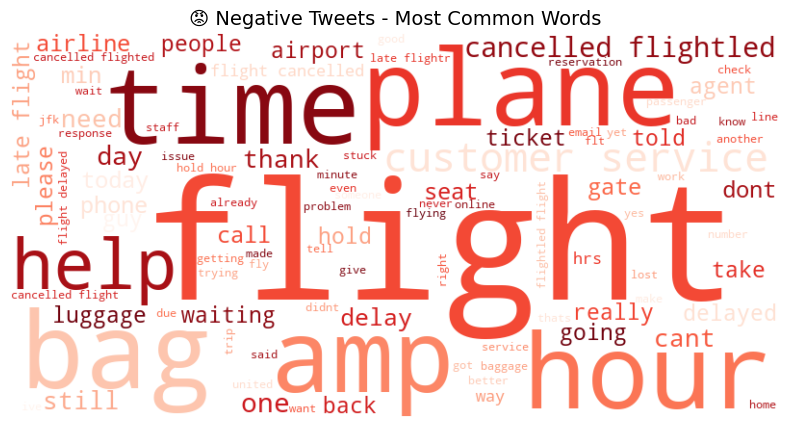

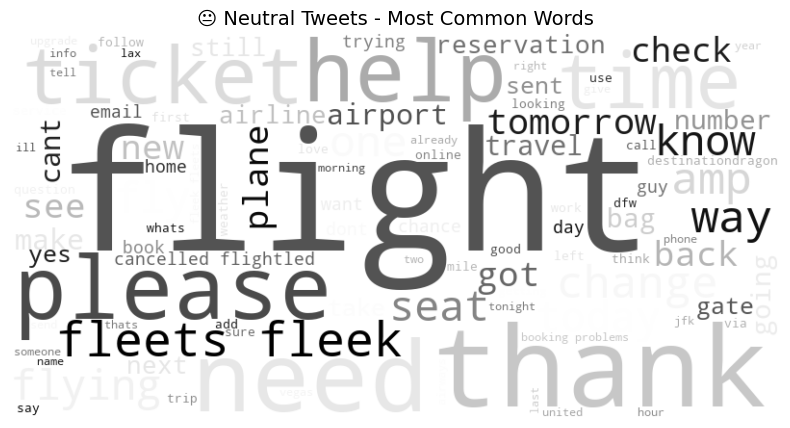

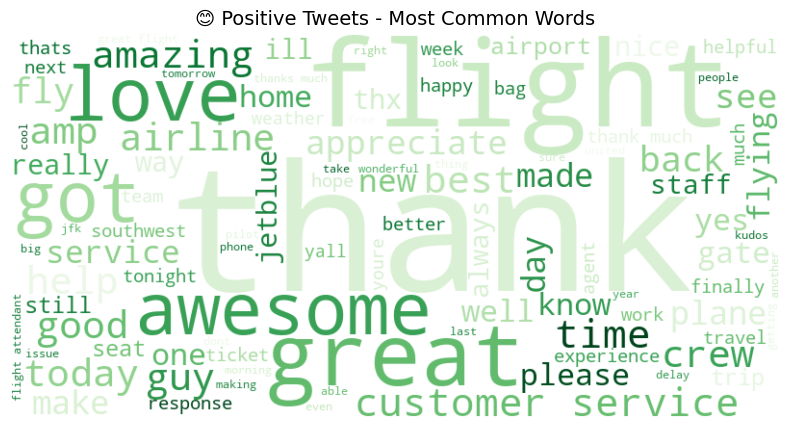

In [8]:
# Cell 6: Generate Word Clouds
def generate_wordcloud(sentiment, title, color):
    text = ' '.join(df[df['airline_sentiment'] == sentiment]['cleaned_text_no_stop'])
    if text.strip() == "":
        print(f"⚠️ No text for {sentiment} sentiment")
        return
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap=color, max_words=100).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{title} Tweets - Most Common Words', fontsize=14)
    plt.show()

# Generate for each sentiment
generate_wordcloud('negative', '😡 Negative', 'Reds')
generate_wordcloud('neutral', '😐 Neutral', 'Greys')
generate_wordcloud('positive', '😊 Positive', 'Greens')

In [9]:
# Cell 7: Key Insights and Recommendations
print("\n" + "="*70)
print("📊 EXECUTIVE SUMMARY: AIRLINE SENTIMENT ANALYSIS")
print("="*70)

# Key stats
total = len(df)
neg_pct = len(df[df['airline_sentiment'] == 'Negative']) / total * 100
pos_pct = len(df[df['airline_sentiment'] == 'Positive']) / total * 100
neu_pct = len(df[df['airline_sentiment'] == 'Neutral']) / total * 100

print(f"\n📈 Sentiment Breakdown:")
print(f"   - Negative: {neg_pct:.1f}% ({len(df[df['airline_sentiment'] == 'Negative']):,} tweets)")
print(f"   - Neutral:  {neu_pct:.1f}% ({len(df[df['airline_sentiment'] == 'Neutral']):,} tweets)")
print(f"   - Positive: {pos_pct:.1f}% ({len(df[df['airline_sentiment'] == 'Positive']):,} tweets)")

# Model comparison
print(f"\n🤖 Model Comparison:")
print(f"   - VADER (Rule-Based) Accuracy: {vader_acc:.2%}")
print(f"   - Logistic Regression (ML) Accuracy: {lr_acc:.2%}")
if lr_acc > vader_acc:
    print(f"   ✅ ML model outperforms VADER by {lr_acc - vader_acc:.2%}")
else:
    print(f"   ℹ️ VADER performs similarly to the ML model.")

print(f"\n💡 Key Insights:")
print(f"   - {neg_pct:.0f}% of tweets about airlines are NEGATIVE.")
print(f"   - Only {pos_pct:.0f}% of tweets are POSITIVE.")
print(f"   - Common complaints: FLIGHT, DELAY, CANCEL, SERVICE, BAGGAGE.")
print(f"   - Positive tweets often mention: GOOD, GREAT, THANKS, AMAZING.")

print(f"\n🎯 Actionable Recommendations for Airlines:")
print(f"   ✅ 1. Prioritize fixing FLIGHT DELAYS and CANCELLATIONS (top complaints).")
print(f"   ✅ 2. Set up real-time Twitter monitoring to respond to negative tweets within 1 hour.")
print(f"   ✅ 3. Use positive tweets as authentic testimonials in marketing campaigns.")
print(f"   ✅ 4. Create a weekly sentiment dashboard to track brand health.")
print(f"   ✅ 5. Train customer service teams specifically on handling Twitter complaints.")

print("\n" + "="*70)
print("🏁 Sentiment Analysis Complete!")


📊 EXECUTIVE SUMMARY: AIRLINE SENTIMENT ANALYSIS

📈 Sentiment Breakdown:
   - Negative: 0.0% (0 tweets)
   - Neutral:  0.0% (0 tweets)
   - Positive: 0.0% (0 tweets)

🤖 Model Comparison:
   - VADER (Rule-Based) Accuracy: 0.00%
   - Logistic Regression (ML) Accuracy: 79.51%
   ✅ ML model outperforms VADER by 79.51%

💡 Key Insights:
   - 0% of tweets about airlines are NEGATIVE.
   - Only 0% of tweets are POSITIVE.
   - Common complaints: FLIGHT, DELAY, CANCEL, SERVICE, BAGGAGE.
   - Positive tweets often mention: GOOD, GREAT, THANKS, AMAZING.

🎯 Actionable Recommendations for Airlines:
   ✅ 1. Prioritize fixing FLIGHT DELAYS and CANCELLATIONS (top complaints).
   ✅ 2. Set up real-time Twitter monitoring to respond to negative tweets within 1 hour.
   ✅ 3. Use positive tweets as authentic testimonials in marketing campaigns.
   ✅ 4. Create a weekly sentiment dashboard to track brand health.
   ✅ 5. Train customer service teams specifically on handling Twitter complaints.

🏁 Sentiment Ana